In [1]:
import lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from lifelines import (
    WeibullFitter, 
    ExponentialFitter, 
    LogNormalFitter, 
    LogLogisticFitter, 
    WeibullAFTFitter, 
    LogNormalAFTFitter, 
    LogLogisticAFTFitter, 
    PiecewiseExponentialFitter
)


In [3]:
telco = pd.read_csv('telco.csv') 
telco

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Zone 3,10,39,Unmarried,0,27,Some college,No,Female,No,No,No,Basic service,No
996,997,Zone 1,7,34,Unmarried,2,22,Post-undergraduate degree,No,Female,No,No,No,Basic service,No
997,998,Zone 3,67,59,Unmarried,40,944,Post-undergraduate degree,No,Female,Yes,Yes,Yes,Total service,No
998,999,Zone 3,70,49,Unmarried,18,87,High school degree,No,Female,Yes,No,Yes,Plus service,No


There are a few categorical columns which need to be encoded.

In [4]:
categorical_cols = ['region', 'marital', 'ed', 'retire', 'gender',
                    'voice', 'internet', 'forward', 'custcat']

telco_encoded = pd.get_dummies(telco, columns=categorical_cols, drop_first=True)

In [5]:
telco_encoded.columns

Index(['ID', 'tenure', 'age', 'address', 'income', 'churn', 'region_Zone 2',
       'region_Zone 3', 'marital_Unmarried', 'ed_Did not complete high school',
       'ed_High school degree', 'ed_Post-undergraduate degree',
       'ed_Some college', 'retire_Yes', 'gender_Male', 'voice_Yes',
       'internet_Yes', 'forward_Yes', 'custcat_E-service',
       'custcat_Plus service', 'custcat_Total service'],
      dtype='object')

In [6]:
telco_encoded

,ID,tenure,age,address,income,churn,region_Zone 2,region_Zone 3,marital_Unmarried,ed_Did not complete high school,...,ed_Post-undergraduate degree,ed_Some college,retire_Yes,gender_Male,voice_Yes,internet_Yes,forward_Yes,custcat_E-service,custcat_Plus service,custcat_Total service
0,1,13,44,9,64,Yes,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,2,11,33,7,136,Yes,False,True,False,False,...,True,False,False,True,True,False,True,False,False,True
2,3,68,52,24,116,No,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False
3,4,33,33,12,33,Yes,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,5,23,30,9,30,No,True,False,False,True,...,False,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,10,39,0,27,No,False,True,True,False,...,False,True,False,False,False,False,False,False,False,False
996,997,7,34,2,22,No,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
997,998,67,59,40,944,No,False,True,True,False,...,True,False,False,False,True,True,True,False,False,True
998,999,70,49,18,87,No,False,True,True,False,...,False,False,False,False,True,False,True,False,True,False


In [7]:
telco_encoded['churn'] = telco_encoded['churn'].map({'Yes': 1, 'No': 0})

In [8]:
survival = telco_encoded

In [9]:
survival.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   ID                               1000 non-null   int64
 1   tenure                           1000 non-null   int64
 2   age                              1000 non-null   int64
 3   address                          1000 non-null   int64
 4   income                           1000 non-null   int64
 5   churn                            1000 non-null   int64
 6   region_Zone 2                    1000 non-null   bool 
 7   region_Zone 3                    1000 non-null   bool 
 8   marital_Unmarried                1000 non-null   bool 
 9   ed_Did not complete high school  1000 non-null   bool 
 10  ed_High school degree            1000 non-null   bool 
 11  ed_Post-undergraduate degree     1000 non-null   bool 
 12  ed_Some college                  1000 non-null   

There are no non-null values available in the dataset

# Building Accelerated Failure Time Models

In [10]:
wb = WeibullFitter()
ex = ExponentialFitter()
log = LogNormalFitter()
loglogis = LogLogisticFitter()


## Weibull distribution

In [11]:
we_aft = WeibullAFTFitter()
we_aft.fit(survival, duration_col='tenure', event_col='churn')
we_aft_pd = we_aft.predict_survival_function(survival).transpose()
avg_we = we_aft_pd.mean().to_list()
we_aft_pd

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0
0,0.995732,0.990209,0.984110,0.977620,0.970837,0.963823,0.956621,0.949264,0.941778,0.934182,...,0.536898,0.530555,0.524267,0.518035,0.511858,0.505737,0.499670,0.493660,0.487704,0.481803
1,0.998199,0.995862,0.993272,0.990506,0.987604,0.984591,0.981484,0.978296,0.975037,0.971715,...,0.769425,0.765581,0.761745,0.757915,0.754093,0.750280,0.746474,0.742676,0.738887,0.735106
2,0.999762,0.999453,0.999110,0.998743,0.998357,0.997955,0.997539,0.997111,0.996672,0.996224,...,0.966032,0.965394,0.964755,0.964114,0.963472,0.962828,0.962182,0.961535,0.960887,0.960238
3,0.994751,0.987967,0.980485,0.972535,0.964240,0.955676,0.946897,0.937946,0.928852,0.919644,...,0.465227,0.458474,0.451798,0.445199,0.438676,0.432230,0.425860,0.419566,0.413347,0.407202
4,0.998299,0.996092,0.993646,0.991034,0.988292,0.985445,0.982508,0.979495,0.976413,0.973272,...,0.780765,0.777081,0.773404,0.769732,0.766067,0.762408,0.758756,0.755111,0.751473,0.747842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.987916,0.972420,0.955492,0.937691,0.919317,0.900564,0.881569,0.862435,0.843242,0.824055,...,0.170710,0.165040,0.159542,0.154210,0.149041,0.144030,0.139174,0.134467,0.129907,0.125490
996,0.983316,0.962036,0.938937,0.914816,0.890102,0.865074,0.839925,0.814802,0.789816,0.765054,...,0.086602,0.082647,0.078861,0.075237,0.071769,0.068452,0.065279,0.062244,0.059342,0.056568
997,0.999615,0.999114,0.998557,0.997962,0.997336,0.996685,0.996011,0.995318,0.994608,0.993883,...,0.945489,0.944477,0.943462,0.942446,0.941428,0.940407,0.939385,0.938361,0.937335,0.936308
998,0.997985,0.995370,0.992474,0.989382,0.986138,0.982771,0.979301,0.975742,0.972105,0.968399,...,0.745774,0.741606,0.737448,0.733300,0.729163,0.725037,0.720923,0.716819,0.712728,0.708648


## Log-Normal

In [12]:
logn_aft = LogNormalAFTFitter()
logn_aft.fit(survival, duration_col='tenure', event_col='churn')
logn_aft_pd = logn_aft.predict_survival_function(survival).transpose()
avg_logn = logn_aft_pd.mean().to_list()
logn_aft_pd


,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0
0,0.999400,0.996630,0.991798,0.985377,0.977771,0.969295,0.960184,0.950616,0.940729,0.930625,...,0.529900,0.525114,0.520399,0.515753,0.511174,0.506662,0.502215,0.497832,0.493511,0.489251
1,0.999872,0.999120,0.997586,0.995320,0.992413,0.988960,0.985044,0.980741,0.976112,0.971212,...,0.689157,0.684897,0.680678,0.676502,0.672366,0.668271,0.664215,0.660200,0.656223,0.652285
2,1.000000,0.999999,0.999994,0.999985,0.999969,0.999945,0.999911,0.999867,0.999811,0.999745,...,0.980761,0.980190,0.979615,0.979034,0.978449,0.977858,0.977264,0.976664,0.976060,0.975452
3,0.998846,0.994103,0.986399,0.976646,0.965509,0.953455,0.940810,0.927806,0.914610,0.901344,...,0.453749,0.448987,0.444306,0.439704,0.435180,0.430731,0.426355,0.422051,0.417817,0.413652
4,0.999941,0.999551,0.998699,0.997378,0.995619,0.993468,0.990968,0.988161,0.985087,0.981777,...,0.753795,0.749989,0.746212,0.742463,0.738743,0.735051,0.731387,0.727752,0.724144,0.720563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.994540,0.978097,0.956026,0.931446,0.905956,0.880409,0.855274,0.830807,0.807144,0.784349,...,0.268130,0.264182,0.260325,0.256555,0.252870,0.249267,0.245743,0.242297,0.238925,0.235626
996,0.985134,0.949949,0.909020,0.867589,0.827587,0.789721,0.754193,0.720988,0.689996,0.661070,...,0.161072,0.158151,0.155309,0.152544,0.149853,0.147232,0.144680,0.142194,0.139772,0.137411
997,1.000000,0.999994,0.999976,0.999940,0.999881,0.999797,0.999685,0.999544,0.999373,0.999172,...,0.959120,0.958055,0.956983,0.955907,0.954826,0.953740,0.952649,0.951554,0.950455,0.949352
998,0.999897,0.999267,0.997959,0.996001,0.993463,0.990423,0.986953,0.983116,0.978969,0.974557,...,0.707810,0.703666,0.699560,0.695491,0.691460,0.687466,0.683508,0.679587,0.675702,0.671852


## Log-Log

In [13]:
loglog_aft = LogLogisticAFTFitter()
loglog_aft.fit(survival, duration_col='tenure', event_col='churn')
loglog_aft_pd = loglog_aft.predict_survival_function(survival).transpose()
avg_loglog = loglog_aft_pd.mean().to_list() 
loglog_aft_pd


,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0
0,0.997306,0.992858,0.987403,0.981203,0.974413,0.967141,0.959468,0.951459,0.943168,0.934641,...,0.514846,0.509286,0.503810,0.498416,0.493104,0.487872,0.482719,0.477644,0.472646,0.467722
1,0.998828,0.996885,0.994489,0.991748,0.988723,0.985457,0.981982,0.978321,0.974495,0.970521,...,0.709570,0.704963,0.700386,0.695839,0.691323,0.686838,0.682383,0.677960,0.673568,0.669208
2,0.999929,0.999810,0.999663,0.999494,0.999306,0.999103,0.998885,0.998653,0.998410,0.998155,...,0.975700,0.975166,0.974630,0.974091,0.973550,0.973005,0.972458,0.971908,0.971356,0.970801
3,0.996363,0.990373,0.983052,0.974765,0.965731,0.956103,0.945997,0.935505,0.924705,0.913661,...,0.439870,0.434395,0.429020,0.423743,0.418563,0.413477,0.408483,0.403580,0.398764,0.394035
4,0.999161,0.997768,0.996049,0.994079,0.991901,0.989546,0.987035,0.984385,0.981609,0.978719,...,0.773393,0.769469,0.765560,0.761666,0.757787,0.753924,0.750076,0.746245,0.742431,0.738634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.991091,0.976620,0.959272,0.940068,0.919636,0.898419,0.876744,0.854863,0.832970,0.811217,...,0.241783,0.237727,0.233780,0.229937,0.226196,0.222553,0.219004,0.215546,0.212176,0.208891
996,0.981444,0.952063,0.918023,0.881766,0.844741,0.807881,0.771794,0.736873,0.703358,0.671385,...,0.131654,0.129131,0.126687,0.124319,0.122024,0.119799,0.117641,0.115547,0.113514,0.111540
997,0.999796,0.999457,0.999037,0.998554,0.998019,0.997438,0.996817,0.996158,0.995466,0.994742,...,0.933506,0.932112,0.930712,0.929308,0.927899,0.926486,0.925068,0.923647,0.922221,0.920792
998,0.998882,0.997028,0.994741,0.992124,0.989236,0.986116,0.982795,0.979296,0.975639,0.971838,...,0.719169,0.714653,0.710164,0.705703,0.701271,0.696867,0.692491,0.688145,0.683827,0.679538


## Survival curves 

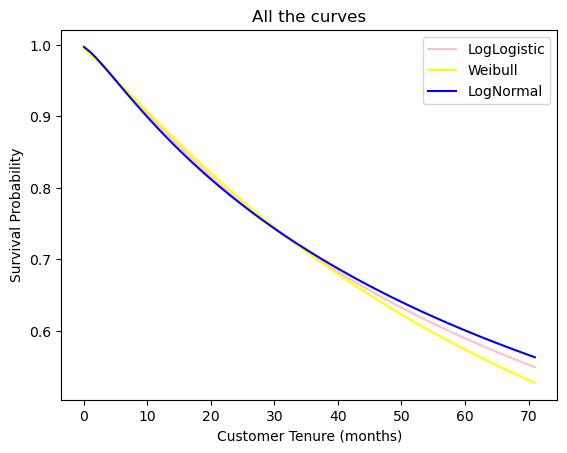

In [14]:
plt.plot(avg_loglog, color = 'pink', label = 'LogLogistic')
plt.plot(avg_we, color = "yellow", label = "Weibull")
plt.plot(avg_logn, color = "blue", label = "LogNormal")
plt.title("Survival Curves for Different AFT Models")
plt.xlabel("Customer Tenure (months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.title("All the curves")
plt.show()

#Did not include exponential as it is a special case of weibull distribution.

In [15]:
for model in [wb, ex, log, loglogis]:
    model.fit(durations = survival["tenure"], event_observed = survival["churn"])
    print("The AIC value for", model.__class__.__name__, "is",  model.AIC_)

The AIC value for WeibullFitter is 3216.8611706815464
The AIC value for ExponentialFitter is 3215.9608134637247
The AIC value for LogNormalFitter is 3209.0351474316735
The AIC value for LogLogisticFitter is 3214.4154757933375


Lower AIC indicates a better model (in terms of goodness-of-fit vs. complexity). The lower the AIC value, the better the model is at fitting the data. In terms of complexity, the Exponential model is the simplest as it has one main parameter, but since our dataset is pretty small, we can ignore the complexity part and just go with the AIC value as it incountears complexity as well. The LogNormalFitter model has the lowest AIC value among the models, with a value of close to 3209. This suggests that the log-normal distribution may be the best fit for the data. AIC penalizes more complex models, so LogNormal achieves better fit with reasonable complexity.

In [16]:
logn_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1454.15
         time fit was run = 2025-05-01 18:52:24 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
mu_    ID                              -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
       address                          0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                              0.03      1.03      0.01            0.02            0.05                1.02                1.05
       custcat_E-service                1.06      2.90      0.17            0.73            1.40                2.08                4.04
       custcat_Plus service             0.94      2.55      0.22            0.52            1.36                1.68                3.89
       custcat_Total service            1.21      3.35      0.25            0.72            1.70                2.06                5.47
       ed_Did not complete high school  0.38      1.46      0.20           -0.02            0.77                0.98                2.16
       ed_High school degree            0.31      1.36      0.16           -0.01            0.62                0.99                1.87
       ed_Post-undergraduate degree    -0.05      0.95      0.22           -0.49            0.38                0.61                1.46
       ed_Some college                  0.29      1.33      0.16           -0.04            0.61                0.96                1.84
       forward_Yes                     -0.20      0.82      0.18           -0.56            0.15                0.57                1.16
       gender_Male                      0.04      1.04      0.11           -0.19            0.26                0.83                1.30
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.79      0.45      0.14           -1.07           -0.51                0.34                0.60
       marital_Unmarried               -0.44      0.64      0.11           -0.67           -0.22                0.51                0.80
       region_Zone 2                   -0.09      0.91      0.14           -0.37            0.18                0.69                1.20
       region_Zone 3                    0.06      1.06      0.14           -0.22            0.34                0.81                1.40
       retire_Yes                       0.02      1.02      0.44           -0.85            0.89                0.43                2.44
       voice_Yes                       -0.41      0.66      0.17           -0.74           -0.08                0.48                0.92
       Intercept                        2.57     13.09      0.30            1.97            3.17                7.20               23.78
sigma_ Intercept                        0.27      1.31      0.05            0.18            0.36                1.20                1.43

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
mu_    ID                                 0.00 -2.39   0.02      5.89
       address                            0.00  4.80 <0.005     19.27
       age                                0.00  4.59 <0.005     17.78
       custcat_E-service                  0.00  6.28 <0.005     31.42
       custcat_Plus service               0.00  4.36 <0.005     16.22
       custcat_Total serv

# Selectng only the significant features

In [17]:
significant_features = logn_aft.summary[logn_aft.summary['p'] < 0.05].index
significant_features

MultiIndex([(   'mu_',                    'ID'),
            (   'mu_',               'address'),
            (   'mu_',                   'age'),
            (   'mu_',     'custcat_E-service'),
            (   'mu_',  'custcat_Plus service'),
            (   'mu_', 'custcat_Total service'),
            (   'mu_',          'internet_Yes'),
            (   'mu_',     'marital_Unmarried'),
            (   'mu_',             'voice_Yes'),
            (   'mu_',             'Intercept'),
            ('sigma_',             'Intercept')],
           names=['param', 'covariate'])

We can see that Address, Age,Customer Category, Internet, Voice Incuded, and Marital Status are significant features.

In [18]:
final_data = survival[['tenure', 'address', 'age', 'marital_Unmarried','internet_Yes', 'voice_Yes', 
              'custcat_E-service','custcat_Plus service','custcat_Total service', 'churn' ]]


In [19]:
final_data

,tenure,address,age,marital_Unmarried,internet_Yes,voice_Yes,custcat_E-service,custcat_Plus service,custcat_Total service,churn
0,13,9,44,False,False,False,False,False,False,1
1,11,7,33,False,False,True,False,False,True,1
2,68,24,52,False,False,False,False,True,False,0
3,33,12,33,True,False,False,False,False,False,1
4,23,9,30,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...
995,10,0,39,True,False,False,False,False,False,0
996,7,2,34,True,False,False,False,False,False,0
997,67,40,59,True,True,True,False,False,True,0
998,70,18,49,True,False,True,False,True,False,0


In [20]:
logn_aft_final = LogNormalAFTFitter()
logn_aft_final.fit(final_data, duration_col='tenure', event_col='churn')
logn_aft_final_pd = logn_aft_final.predict_survival_function(final_data).transpose()
logn_aft_final.print_summary() 

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'tenure'
                event col = 'churn'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1462.10
         time fit was run = 2025-05-01 18:52:25 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    address                0.04      1.04      0.01            0.03            0.06                1.03                1.06
       age                    0.04      1.04      0.01            0.02            0.05                1.02                1.05
       custcat_E-service      1.03      2.79      0.17            0.69            1.36                2.00                3.89
       custcat_Plus service   0.82      2.28      0.17            0.49            1.15                1.63                3.17
       custcat_Total service  1.01      2.75      0.21            0.60            1.42                1.83                4.15
       internet_Yes          -0.84      0.43      0.14           -1.11           -0.57                0.33                0.57
       marital_Unmarried     -0.45      0.64      0.11           -0.67           -0.22                0.51                0.80
       voice_Yes             -0.46      0.63      0.17           -0.79           -0.14                0.45                0.87
       Intercept              2.53     12.62      0.24            2.06            3.01                7.84               20.30
sigma_ Intercept              0.28      1.33      0.05            0.19            0.37                1.21                1.45

                              cmp to     z      p  -log2(p)
param  covariate                                           
mu_    address                  0.00  4.84 <0.005     19.56
       age                      0.00  5.75 <0.005     26.78
       custcat_E-service        0.00  6.07 <0.005     29.53
       custcat_Plus service     0.00  4.85 <0.005     19.66
       custcat_Total service    0.00  4.83 <0.005     19.52
       internet_Yes             0.00 -6.08 <0.005     29.63
       marital_Unmarried        0.00 -3.91 <0.005     13.39
       voice_Yes                0.00 -2.78   0.01      7.52
       Intercept                0.00 10.45 <0.005     82.47
sigma_ Intercept                0.00  6.15 <0.005     30.27
---
Concordance = 0.78
AIC = 2944.20
log-likelihood ratio test = 280.83 on 8 df
-log2(p) of ll-ratio test = 183.73

## Coefficient interption

1. For 'address' variable, the exp(coef) of 1.04 shows that, for each additional year staying at the same address, the churn is expected to increase by approximately 4% if other variables stay constant.
2. For 'age' variable, the exp(coef) of 1.04 shows that, for each additional unit increase in age, the hazard of the event (churn) is expected to increase by approximately 4% if other variables stay constant.
3. Basic Service is the baseline for the Customer Category variable. The exp(coef) of 'custcat_E-service' is 2.79, which implies that, compared to the reference category, individuals with e-service are expected to churn approximately 2.79 times higher. The exp(coef) of 'custcat_Plus-service' is 2.28, which shows  that, compared to the reference category, individuals with e-service are 2.28 times more likely to churn. Customers with Total service have an expected time to churn that is 2.75 times longer than Basic service customers.
4. For 'internet_Yes' variable, an exp(coef) of 0.43 shows that having internet decreases the churn by approximately 57%, if other variables stay constant. 
5. For "martial_Unmarried" theexp(coef) of 0.63 shows that having voice services decreses the possibility of the churn by 37%.

We can conclude that being older, living at the same address longer, not having internet or voice services included, being married, not having a Basic Service Category increase the churn risk.

In [21]:
MM = 1300 #Assuming monthly revenue per customer is 1300
sequence = range(1,len(logn_aft_pd.columns)+1)
r = 0.1 #Assuming the discount rate is 0.1

for num in sequence:
    logn_aft_pd.loc[:,num] = logn_aft_pd.loc[:,num]/((1+r/12)**(sequence[num-1]-1))

In [22]:
logn_aft_pd

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0
0,0.999400,0.988393,0.975473,0.961147,0.945847,0.929898,0.913544,0.896967,0.880301,0.863650,...,0.316766,0.311311,0.305965,0.300728,0.295595,0.290564,0.285634,0.280801,0.276063,0.271418
1,0.999872,0.990862,0.981165,0.970846,0.960010,0.948763,0.937197,0.925391,0.913412,0.901315,...,0.411967,0.406037,0.400201,0.394458,0.388806,0.383245,0.377771,0.372384,0.367082,0.361863
2,1.000000,0.991734,0.983534,0.975396,0.967320,0.959302,0.951342,0.943438,0.935589,0.927795,...,0.586283,0.581100,0.575959,0.570860,0.565804,0.560789,0.555816,0.550885,0.545994,0.541144
3,0.998846,0.985887,0.970162,0.952631,0.933985,0.914702,0.895111,0.875444,0.855861,0.836476,...,0.271244,0.266179,0.261227,0.256385,0.251650,0.247018,0.242488,0.238057,0.233721,0.229479
4,0.999941,0.991291,0.982260,0.972853,0.963112,0.953088,0.942833,0.932393,0.921810,0.911121,...,0.450607,0.444626,0.438731,0.432919,0.427190,0.421542,0.415975,0.410486,0.405076,0.399742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.994540,0.970013,0.940289,0.908543,0.876376,0.844625,0.813730,0.783919,0.755297,0.727901,...,0.160284,0.156619,0.153056,0.149593,0.146226,0.142951,0.139766,0.136667,0.133651,0.130716
996,0.985134,0.942098,0.894056,0.846256,0.800566,0.757623,0.717559,0.680298,0.645675,0.613494,...,0.096286,0.093759,0.091313,0.088946,0.086655,0.084436,0.082286,0.080204,0.078186,0.076231
997,1.000000,0.991730,0.983516,0.975352,0.967235,0.959160,0.951127,0.943133,0.935179,0.927264,...,0.573347,0.567977,0.562653,0.557375,0.552143,0.546958,0.541817,0.536722,0.531671,0.526665
998,0.999897,0.991009,0.981532,0.971510,0.961026,0.950167,0.939013,0.927633,0.916085,0.904420,...,0.423118,0.417164,0.411302,0.405530,0.399848,0.394253,0.388744,0.383319,0.377978,0.372719


In [23]:
logn_aft_pd["CLV"] = MM * logn_aft_pd.sum(axis = 1)
logn_aft_pd

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0,CLV
0,0.999400,0.988393,0.975473,0.961147,0.945847,0.929898,0.913544,0.896967,0.880301,0.863650,...,0.311311,0.305965,0.300728,0.295595,0.290564,0.285634,0.280801,0.276063,0.271418,52336.284288
1,0.999872,0.990862,0.981165,0.970846,0.960010,0.948763,0.937197,0.925391,0.913412,0.901315,...,0.406037,0.400201,0.394458,0.388806,0.383245,0.377771,0.372384,0.367082,0.361863,59689.294020
2,1.000000,0.991734,0.983534,0.975396,0.967320,0.959302,0.951342,0.943438,0.935589,0.927795,...,0.581100,0.575959,0.570860,0.565804,0.560789,0.555816,0.550885,0.545994,0.541144,70246.083799
3,0.998846,0.985887,0.970162,0.952631,0.933985,0.914702,0.895111,0.875444,0.855861,0.836476,...,0.266179,0.261227,0.256385,0.251650,0.247018,0.242488,0.238057,0.233721,0.229479,48357.806251
4,0.999941,0.991291,0.982260,0.972853,0.963112,0.953088,0.942833,0.932393,0.921810,0.911121,...,0.444626,0.438731,0.432919,0.427190,0.421542,0.415975,0.410486,0.405076,0.399742,62351.350513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.994540,0.970013,0.940289,0.908543,0.876376,0.844625,0.813730,0.783919,0.755297,0.727901,...,0.156619,0.153056,0.149593,0.146226,0.142951,0.139766,0.136667,0.133651,0.130716,36885.069678
996,0.985134,0.942098,0.894056,0.846256,0.800566,0.757623,0.717559,0.680298,0.645675,0.613494,...,0.093759,0.091313,0.088946,0.086655,0.084436,0.082286,0.080204,0.078186,0.076231,28388.311843
997,1.000000,0.991730,0.983516,0.975352,0.967235,0.959160,0.951127,0.943133,0.935179,0.927264,...,0.567977,0.562653,0.557375,0.552143,0.546958,0.541817,0.536722,0.531671,0.526665,69613.812395
998,0.999897,0.991009,0.981532,0.971510,0.961026,0.950167,0.939013,0.927633,0.916085,0.904420,...,0.417164,0.411302,0.405530,0.399848,0.394253,0.388744,0.383319,0.377978,0.372719,60475.532280


In [24]:
telco["CLV"] = logn_aft_pd.CLV
telco

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn,CLV
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes,52336.284288
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes,59689.294020
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No,70246.083799
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes,48357.806251
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No,62351.350513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Zone 3,10,39,Unmarried,0,27,Some college,No,Female,No,No,No,Basic service,No,36885.069678
996,997,Zone 1,7,34,Unmarried,2,22,Post-undergraduate degree,No,Female,No,No,No,Basic service,No,28388.311843
997,998,Zone 3,67,59,Unmarried,40,944,Post-undergraduate degree,No,Female,Yes,Yes,Yes,Total service,No,69613.812395
998,999,Zone 3,70,49,Unmarried,18,87,High school degree,No,Female,Yes,No,Yes,Plus service,No,60475.532280


# CLV across multiple segments

### Categoric features

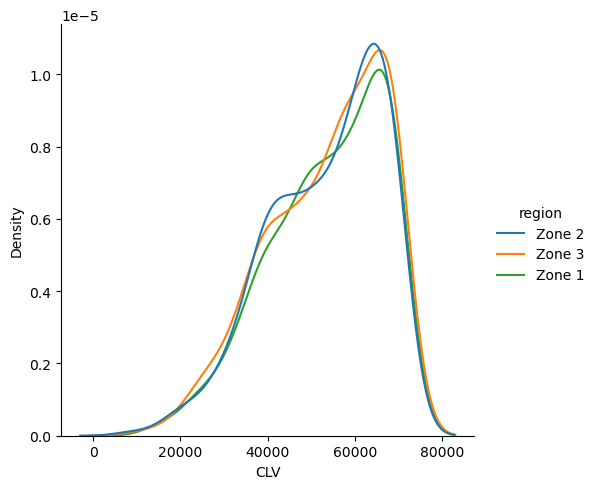

In [25]:
#Region
sns.displot(data=telco, kind='kde', x='CLV', hue='region')

In [26]:
telco.groupby("region")[["CLV"]].mean()

,CLV
region,
Zone 1,53737.782432
Zone 2,53355.418894
Zone 3,53623.236849


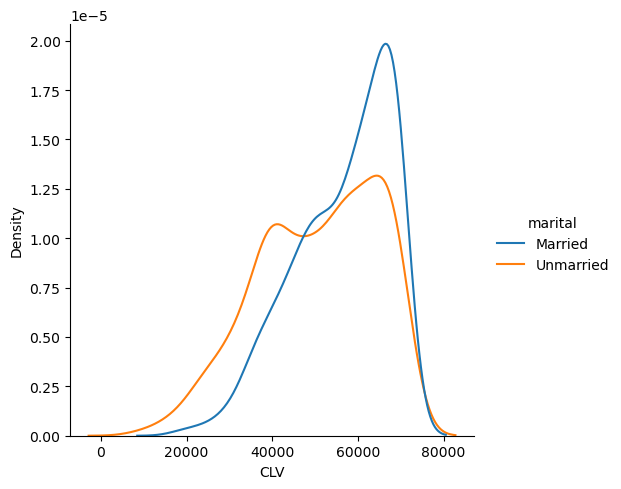

In [27]:
#Martial
sns.displot(data=telco, kind='kde', x='CLV', hue='marital')

In [28]:
telco.groupby("marital")[["CLV"]].mean()

,CLV
marital,
Married,56551.005889
Unmarried,50649.349336


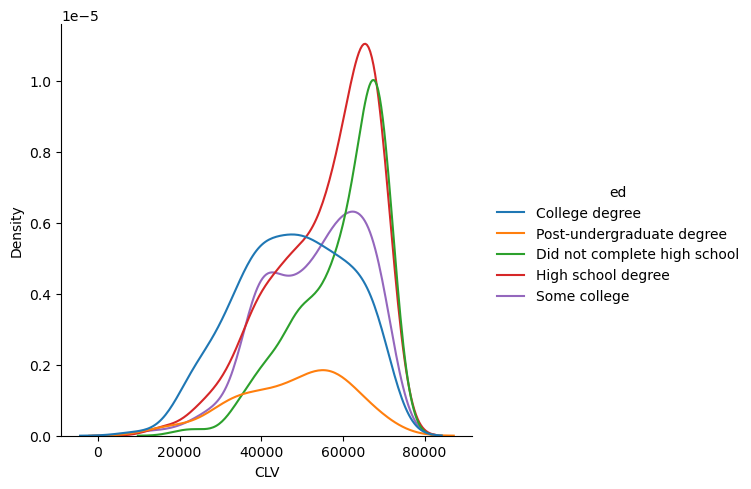

In [29]:
#Education
sns.displot(data=telco, kind='kde', x='CLV', hue='ed')

In [30]:
telco.groupby("ed")[["CLV"]].mean()


,CLV
ed,
College degree,47792.325845
Did not complete high school,59499.145827
High school degree,55640.353168
Post-undergraduate degree,47735.627009
Some college,53254.098523


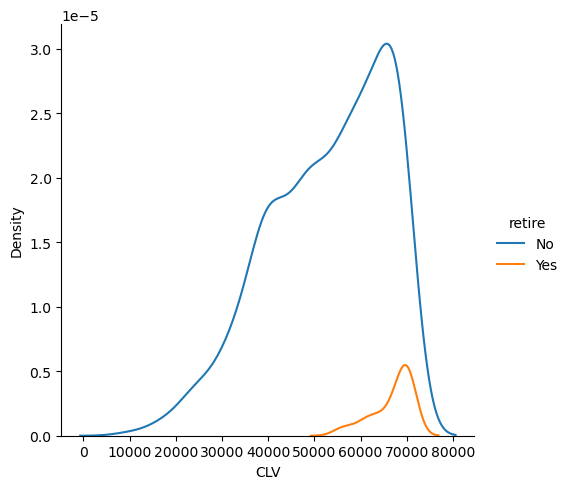

In [31]:
#Retire
sns.displot(data=telco, kind='kde', x='CLV', hue='retire')

In [32]:
telco.groupby("retire")[["CLV"]].mean()

,CLV
retire,
No,52913.916072
Yes,66887.389640


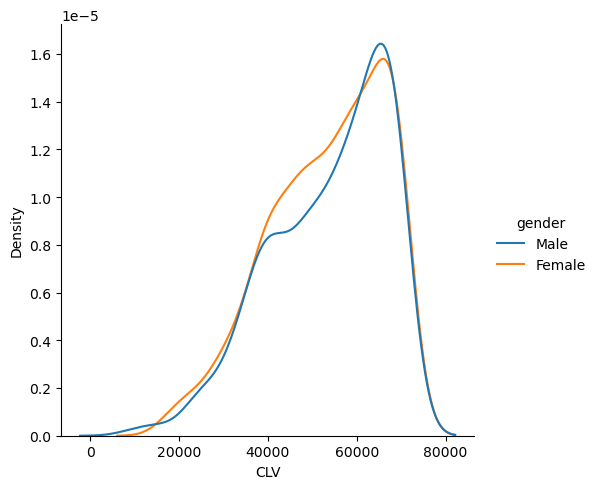

In [33]:
#Gender
sns.displot(data=telco, kind='kde', x='CLV', hue='gender')


In [34]:
telco.groupby("gender")[["CLV"]].mean()

,CLV
gender,
Female,53330.82728
Male,53827.39467


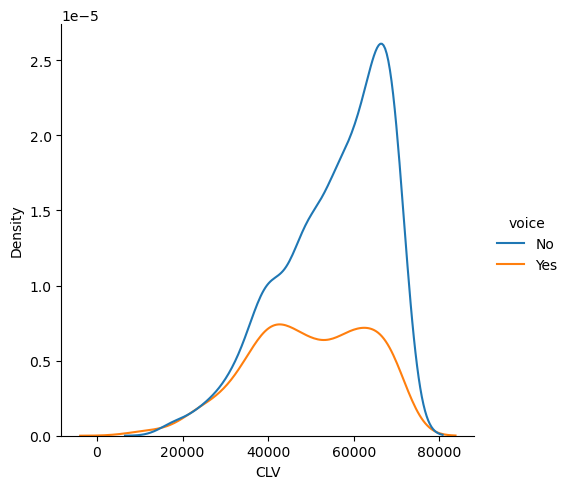

In [35]:
#Voice
sns.displot(data=telco, kind='kde', x='CLV', hue='voice')

In [36]:
telco.groupby("voice")[["CLV"]].mean()

,CLV
voice,
No,55321.569621
Yes,49562.029190


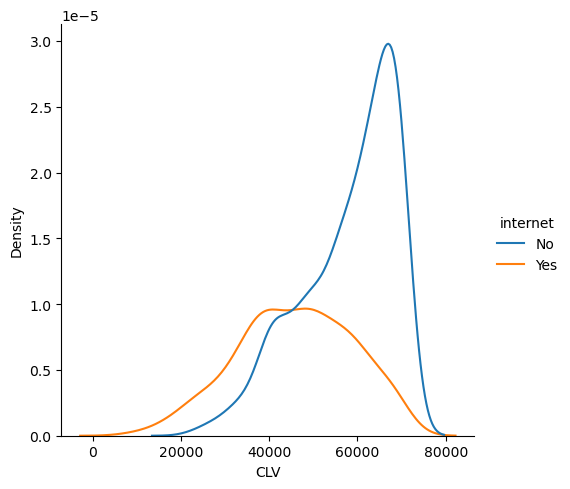

In [37]:
#Internet
sns.displot(data=telco, kind='kde', x='CLV', hue='internet')

In [38]:
telco.groupby("internet")[["CLV"]].mean()

,CLV
internet,
No,58056.698349
Yes,45866.402101


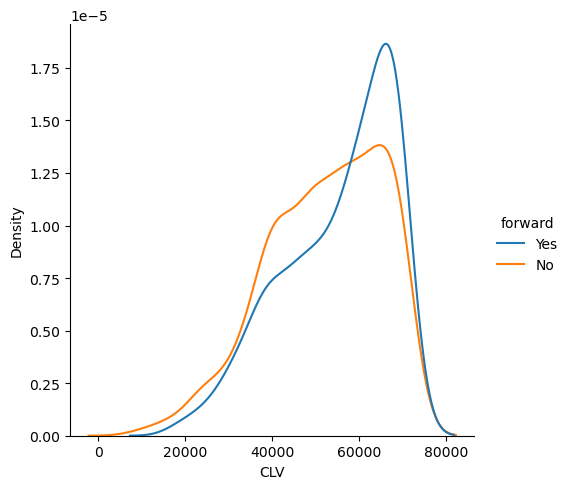

In [39]:
#Forward
sns.displot(data=telco, kind='kde', x='CLV', hue='forward')

In [40]:
telco.groupby("forward")[["CLV"]].mean()

,CLV
forward,
No,52049.579972
Yes,55134.953923


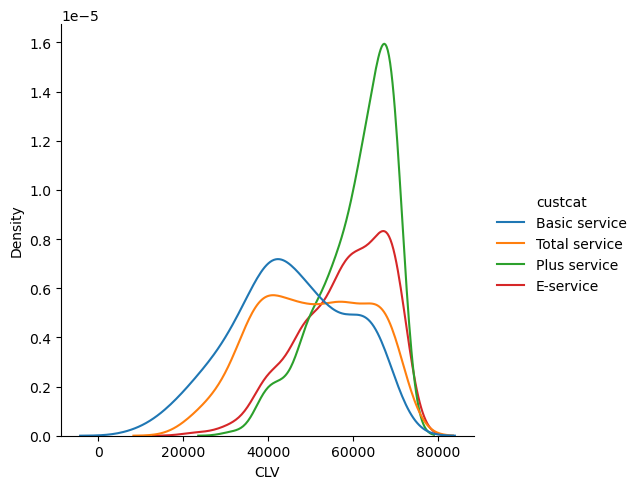

In [41]:
#Custcat
sns.displot(data=telco, kind='kde', x='CLV', hue='custcat')

In [42]:
telco.groupby("custcat")[["CLV"]].mean()

,CLV
custcat,
Basic service,45341.023814
E-service,57902.162421
Plus service,60774.691538
Total service,50286.014523


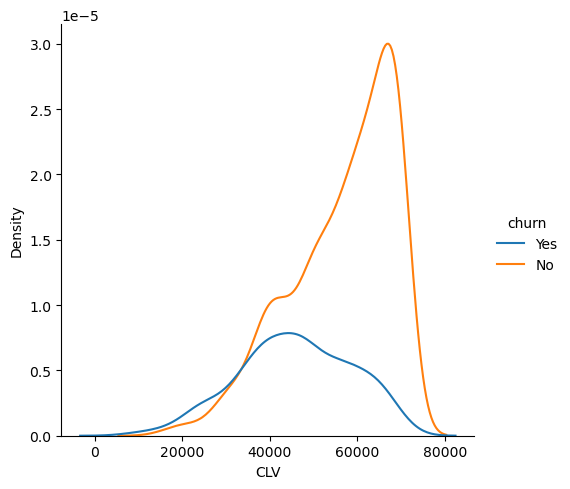

In [43]:
#Churn
sns.displot(data=telco, kind='kde', x='CLV', hue='churn')

In [44]:
telco.groupby("churn")[["CLV"]].mean()

,CLV
churn,
No,56513.693926
Yes,45772.728247


# Annual retention budget

In [45]:
#Customers who have not churned yet(at risk customers)
retained_customers = telco[telco['churn'] == 'No']
at_risk_subscribers = len(retained_customers)

retained_clv = retained_customers['CLV'].mean()
print(f"Retained customers are expected to generate {retained_clv:.2f} in their lifetime.")

#Annual budget calculation if we want to retain 90% of our customers

retention_rate = 0.9 

# If we plan to pay 0.20 percent of each customers CLV in order to retain them
cost_per_customer = retained_clv * 0.20

retention_budget = at_risk_subscribers * retention_rate * cost_per_customer
print(f'Yearly Retention Budget: {retention_budget:.2f}')



Retained customers are expected to generate 56513.69 in their lifetime.
Yearly Retention Budget: 7385209.52


# Key findings(Report)

A valuable segment refers to a group of customers who are expected to generate a high Customer Lifetime Value (CLV). This combines both revenue potential and retention duration(how long are customers likely to stay with the company). 

The most profitable customer segments, based on their average CLV, are retirees, followed by those in the Plus Service customer category, and then those who have not completed high school and that do not have the internet. Therefore, these segments are considered valuable as they have the potential to generate higher profits during their time with the company.

The CLV analysis showed minimal variation across gender and region, suggesting that these variables do not strongly influence customer value. The company may choose to not pay much attention targeted marketing campaigns based solely on these categories, and instead focus on more impactful factors such as service category and education level.

Retention Strategies

1. Plus Service customers contribute a lot to CLV but also have a higher likelihood of churning. The company can start focusing on making their Plus Services worth their price. They can implement personalized retention strategies such as offering loyalty rewards, and exclusive offers now and then. 



2. Pay attention to customer feedback, in order  to build trust with customers.


3. Create blog posts and host events that appeal to college graduates, encouraging them to connect with your brand and spend more on your services